# Model Training for Multi-Class Sentiment Analysis

This notebook loads data prepared in `01data_preparation.ipynb`, trains candidate models, and evaluates them on the validation set. The test set remains untouched until the final model is selected.

## Import Required Libraries

In [ ]:
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  accuracy_score,
  classification_report,
  f1_score,
  )
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

## Load Prepared Data

The pickle file contains TF-IDF matrices, target labels, and a vectorizer fitted exclusively on the training set.

In [ ]:
with open("prepared_data.pkl", "rb") as f:
  (
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    vectorizer,
  ) = pickle.load(f)

validation_texts = pd.read_csv("data/validation_df.csv")["Text"]
class_order = ["bad", "neutral", "good"]

In [ ]:
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val) == len(validation_texts)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert X_train.shape[1] == len(vectorizer.get_feature_names_out())
assert set(y_train.unique()) == set(class_order)

summary = pd.DataFrame({
  "dataset": ["train", "validation", "test"],
  "num_examples": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
  "num_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})
display(summary)

for name, labels in [("train", y_train), ("validation", y_val), ("test", y_test)]:
  print(f"\nClass distribution - {name}:")
  print(labels.value_counts().reindex(class_order, fill_value=0))

,skup,broj_primera,broj_atributa
0,train,36000,10000
1,validation,7500,10000
2,test,7500,10000



Raspodela klasa - train:
Score
bad        12000
good       12000
neutral    12000
Name: count, dtype: int64

Raspodela klasa - validation:
Score
bad         847
good       5965
neutral     688
Name: count, dtype: int64

Raspodela klasa - test:
Score
bad         850
good       5937
neutral     713
Name: count, dtype: int64


## Baseline: Multinomial Logistic Regression

The model is trained only on the training set. The validation set is used for the initial performance estimate and subsequent model comparison.

In [29]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

In [ ]:
print(f"Validation accuracy:    {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation macro F1:    {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Validation weighted F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred, labels=class_order, digits=4))

Validation accuracy:    0.8284
Validation macro F1:    0.7121
Validation weighted F1: 0.8467

Classification report:

              precision    recall  f1-score   support

         bad     0.6524    0.8111    0.7232       847
        good     0.9740    0.8417    0.9031      5965
     neutral     0.3909    0.7340    0.5101       688

    accuracy                         0.8284      7500
   macro avg     0.6724    0.7956    0.7121      7500
weighted avg     0.8842    0.8284    0.8467      7500



NameError: name 'class_order' is not defined

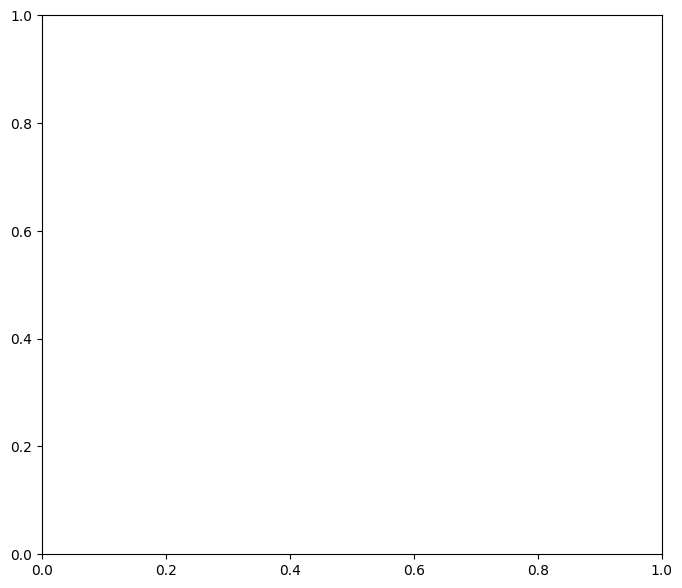

In [49]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred,
  labels=class_order,
  cmap="Blues",
  ax=ax,
  colorbar=False,
  )
ax.set_title("Confusion Matrix - Validation Set")
plt.show()

## LinearSVC and `C` Parameter Tuning

`LinearSVC` learns linear decision boundaries and performs well with sparse TF-IDF matrices. The `C` parameter controls regularization strength: a smaller `C` means stronger regularization. The best value is selected using macro F1 on the validation set.

In [ ]:
c_values = [0.01, 0.03, 0.1, 0.3, 1.0]
svc_results = []
svc_models = {}

for c_value in c_values:
  candidate = LinearSVC(
    C=c_value,
    dual=True,
    max_iter=5000,
    random_state=42,
  )
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  svc_models[c_value] = candidate
  svc_results.append({
    "C": c_value,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

svc_results_df = pd.DataFrame(svc_results)
display(svc_results_df.round(4))

best_c = svc_results_df.loc[svc_results_df["macro_f1"].idxmax(), "C"]
best_svc = svc_models[best_c]
y_val_pred_svc = best_svc.predict(X_val)

print(f"Best C by validation macro F1: {best_c}")

,C,accuracy,macro_f1,weighted_f1
0,0.01,0.8071,0.6732,0.8272
1,0.03,0.8215,0.6948,0.8398
2,0.10,0.8332,0.7124,0.8497
3,0.30,0.8341,0.7154,0.8508
4,1.00,0.8232,0.7013,0.8420


Najbolji C prema validation macro F1: 0.3


In [ ]:
print(f"LinearSVC validation accuracy:    {accuracy_score(y_val, y_val_pred_svc):.4f}")
print(f"LinearSVC validation macro F1:    {f1_score(y_val, y_val_pred_svc, average='macro'):.4f}")
print(f"LinearSVC validation weighted F1: {f1_score(y_val, y_val_pred_svc, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred_svc, labels=class_order, digits=4))

LinearSVC validation accuracy:    0.8341
LinearSVC validation macro F1:    0.7154
LinearSVC validation weighted F1: 0.8508

Classification report:

              precision    recall  f1-score   support

         bad     0.6537    0.8135    0.7249       847
        good     0.9726    0.8508    0.9076      5965
     neutral     0.4007    0.7151    0.5136       688

    accuracy                         0.8341      7500
   macro avg     0.6756    0.7931    0.7154      7500
weighted avg     0.8841    0.8341    0.8508      7500



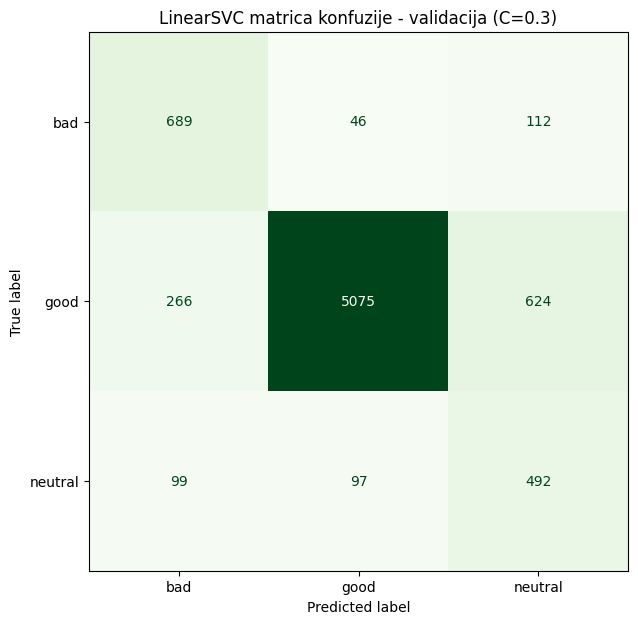

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred_svc,
  labels=class_order,
  cmap="Greens",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"LinearSVC Confusion Matrix - Validation (C={best_c:g})")
plt.show()

## Additional Candidate

In addition to logistic regression and `LinearSVC`, we evaluate `ComplementNB`, which is designed for non-negative, sparse TF-IDF features.

In [ ]:
nb_results = []
nb_models = {}

for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
  candidate = ComplementNB(alpha=alpha)
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  nb_models[alpha] = candidate
  nb_results.append({
    "alpha": alpha,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

nb_results_df = pd.DataFrame(nb_results)
display(nb_results_df.round(4))

best_alpha = nb_results_df.loc[nb_results_df["macro_f1"].idxmax(), "alpha"]
best_nb = nb_models[best_alpha]
y_val_pred_nb = best_nb.predict(X_val)
print(f"Best alpha by validation macro F1: {best_alpha}")

,alpha,accuracy,macro_f1,weighted_f1
0,0.1,0.8123,0.6753,0.8297
1,0.5,0.8155,0.6788,0.8324
2,1.0,0.8163,0.6793,0.8329
3,2.0,0.8196,0.6836,0.8359
4,5.0,0.8197,0.6862,0.8366


Najbolji alpha prema validation macro F1: 5.0


## Model Comparison and Validation Error Analysis

In [ ]:
validation_predictions = {
  "LogisticRegression": y_val_pred,
  "LinearSVC": y_val_pred_svc,
  "ComplementNB": y_val_pred_nb,
}

comparison_rows = []
for model_name, predictions in validation_predictions.items():
  comparison_rows.append({
    "model": model_name,
    "accuracy": accuracy_score(y_val, predictions),
    "macro_f1": f1_score(y_val, predictions, average="macro"),
    "weighted_f1": f1_score(y_val, predictions, average="weighted"),
  })

comparison_df = (
  pd.DataFrame(comparison_rows)
  .sort_values("macro_f1", ascending=False)
  .reset_index(drop=True)
  )
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "model"]
best_validation_pred = validation_predictions[best_model_name]
print(f"Selected model by validation macro F1: {best_model_name}")

,model,accuracy,macro_f1,weighted_f1
0,LinearSVC,0.8341,0.7154,0.8508
1,LogisticRegression,0.8284,0.7121,0.8467
2,ComplementNB,0.8197,0.6862,0.8366


Izabrani model prema validation macro F1: LinearSVC


In [41]:
validation_analysis = pd.DataFrame({
  "text": validation_texts.astype(str),
  "actual": np.asarray(y_val),
  "predicted": best_validation_pred,
})
validation_analysis["is_misclassified"] = (
  validation_analysis["actual"] != validation_analysis["predicted"]
  )

confusion_pairs = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .groupby(["actual", "predicted"])
  .size()
  .sort_values(ascending=False)
  .rename("count")
  .reset_index()
  )
display(confusion_pairs.head(10))

misclassified_examples = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .head(10)
  .copy()
  )
misclassified_examples["text"] = misclassified_examples["text"].str.slice(0, 300)
display(misclassified_examples)

,actual,predicted,count
0,good,neutral,624
1,good,bad,266
2,bad,neutral,112
3,neutral,bad,99
4,neutral,good,97
5,bad,good,46


,text,actual,predicted,is_misclassified
3,This is the fifth different type of coffee I'v...,good,neutral,True
18,If You like haribos gummi bears You'll like th...,good,neutral,True
34,THIS LAPSONSONG SOUCHONG TEA DOES NOT TAST THE...,neutral,bad,True
36,I am always looking to keep my calorie/protein...,good,bad,True
42,"Unless it has real, live Pop Rocks that actual...",neutral,bad,True
51,This tastes fantastic. My only complaint is th...,good,neutral,True
56,Rich flavor and pleasing aroma. This pod conta...,good,neutral,True
60,"Kind of hard to review cat food. After all, th...",good,neutral,True
71,These are great treats - in fact they are the ...,neutral,bad,True
79,Great product for dogs with grain allergies. N...,good,bad,True


## Final Evaluation on the Test Set

After selecting the model exclusively by validation macro F1, the test set is used once for the final unbiased evaluation.

Konačni model: LinearSVC
Test accuracy: 0.8303
Test macro_f1: 0.7118
Test weighted_f1: 0.8469

Test classification report:

              precision    recall  f1-score   support

         bad     0.6181    0.8188    0.7045       850
        good     0.9750    0.8461    0.9059      5937
     neutral     0.4157    0.7125    0.5251       713

    accuracy                         0.8303      7500
   macro avg     0.6696    0.7925    0.7118      7500
weighted avg     0.8814    0.8303    0.8469      7500



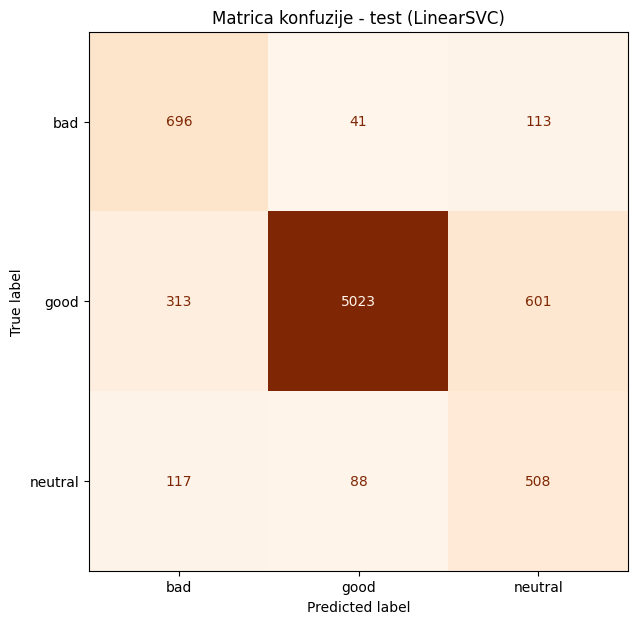

In [ ]:
if best_model_name == "LogisticRegression":
  final_model = model
elif best_model_name == "LinearSVC":
  final_model = best_svc
else:
  final_model = best_nb

y_test_pred = final_model.predict(X_test)

test_metrics = {
  "accuracy": accuracy_score(y_test, y_test_pred),
  "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
  "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
}

print(f"Final model: {best_model_name}")
for metric_name, metric_value in test_metrics.items():
  print(f"Test {metric_name}: {metric_value:.4f}")
print("\nTest classification report:\n")
print(classification_report(y_test, y_test_pred, labels=class_order, digits=4))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_test,
  y_test_pred,
  labels=class_order,
  cmap="Oranges",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"Confusion Matrix - Test ({best_model_name})")
plt.show()

In [ ]:
model_artifact = {
  "model_name": best_model_name,
  "model": final_model,
  "vectorizer": vectorizer,
  "validation_results": comparison_df,
  "test_metrics": test_metrics,
  "classes": class_order,
  "feature_count": X_train.shape[1],
}

joblib.dump(model_artifact, "sentiment_model.joblib")
print("Model saved to sentiment_model.joblib")

Model je sačuvan u sentiment_model.joblib
